###Problem Statement

● Strategic Expansion: Yulu's decision to enter the Indian market is a strategic move to expand its global footprint. Understanding the demand factors in this new market is essential to tailor their services and strategies accordingly

● Revenue Recovery: Yulu's recent revenue decline is a pressing concern. By analyzing the
factors affecting demand for shared electric cycles in the Indian market, they can make
informed adjustments to regain profitability.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import norm
from scipy.stats import ttest_ind
import math

In [2]:
yulu_path = "/content/drive/MyDrive/Colab Notebooks/Business Case Study/Yulu Hypothesis Testing Case Study - 4/bike_sharing.csv"

In [3]:
df = pd.read_csv(yulu_path)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


###Basic Checks

In [4]:
df.shape

(10886, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [7]:
#Checking for null values
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [8]:
#Remove duplicated values
df.duplicated(keep=False).value_counts()

,count
False,10886


###Graphical analysis of numerical features


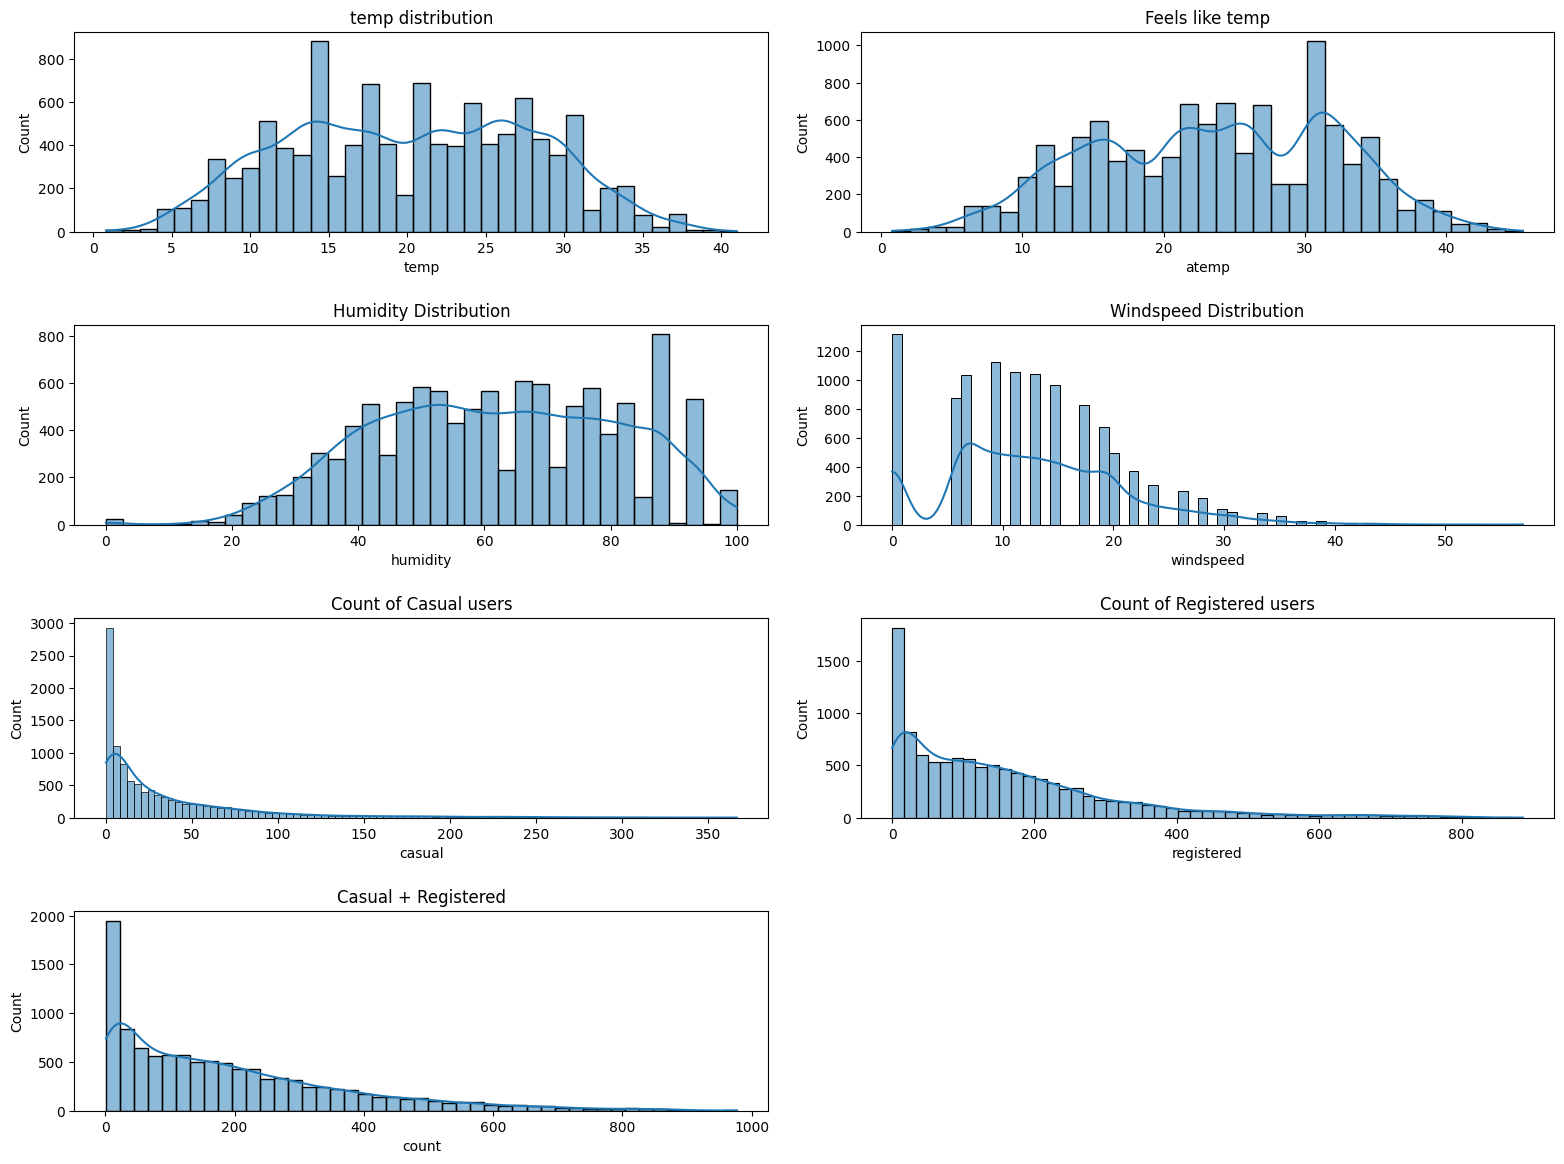

In [9]:
plt.figure(figsize=[16,12])

plt.subplot(4,2,1)
sns.histplot(data=df,x=df['temp'],kde=True)
plt.title("temp distribution")
plt.tight_layout(pad=2.0)


plt.subplot(4,2,2)
sns.histplot(data=df,x=df['atemp'],kde=True)
plt.title("Feels like temp")
plt.tight_layout(pad=2.0)


plt.subplot(4,2,3)
sns.histplot(data=df,x=df['humidity'],kde=True)
plt.title("Humidity Distribution")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,4)
sns.histplot(data=df,x=df['windspeed'],kde=True)
plt.title("Windspeed Distribution")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,5)
sns.histplot(data=df,x=df['casual'],kde=True)
plt.title("Count of Casual users")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,6)
sns.histplot(data=df,x=df['registered'],kde=True)
plt.title("Count of Registered users")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,7)
sns.histplot(data=df,x=df['count'],kde=True)
plt.title("Casual + Registered")
plt.tight_layout(pad=2.0)
plt.show()

Count of casual users, registered users and casual + registered users have positive skew.

Windspeed also almost has a positive skew.

temp, atemp and humidity have almost normal distribution.

###Graphical Analysis of Categorical variables

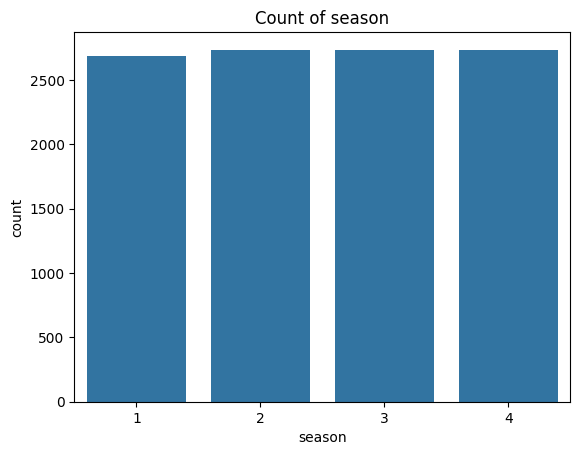

In [10]:
sns.countplot(data=df,x=df['season'])
plt.title("Count of season")
plt.show()

Equal spread of data for all 4 seasons

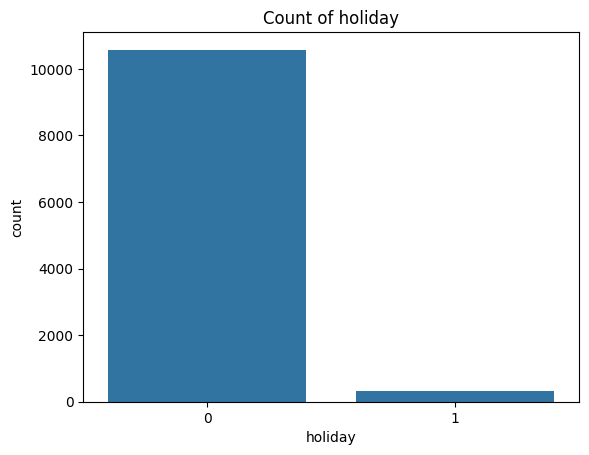

In [11]:
sns.countplot(data=df,x=df['holiday'])
plt.title("Count of holiday")
plt.show()

Most of bike rentals are on non-holidays. This could mean demand is more on workdays/weekends

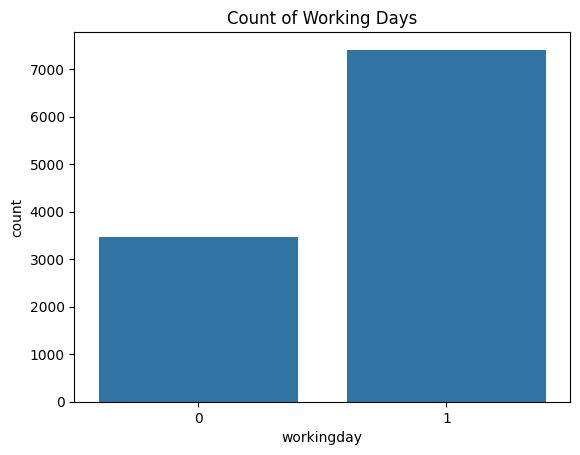

In [12]:
sns.countplot(data=df,x=df['workingday'])
plt.title("Count of Working Days")
plt.show()

More demand is seen on working days compared to weekends. This means majority of users are renting bikes for travelling to work. This makes sense due to high population of India there is more traffic for vehicles.

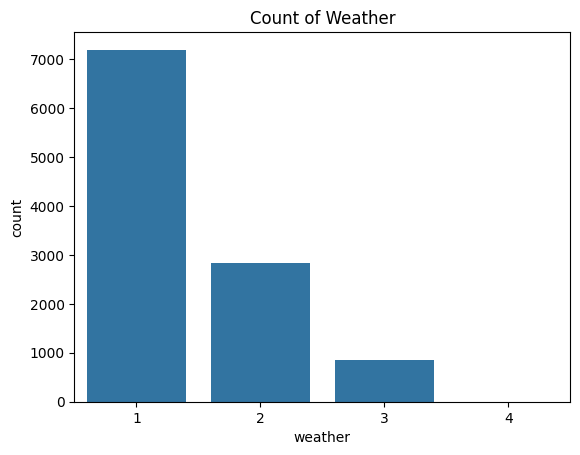

In [14]:
sns.countplot(data=df,x=df['weather'])
plt.title("Count of Weather")
plt.show()

There is more occurence of users renting bikes in

1 - Clear, Few clouds, partly cloudy

fewer in

2 - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

even lesser in

3 - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain +
Scattered clouds

###Checking for outliers in numerical data

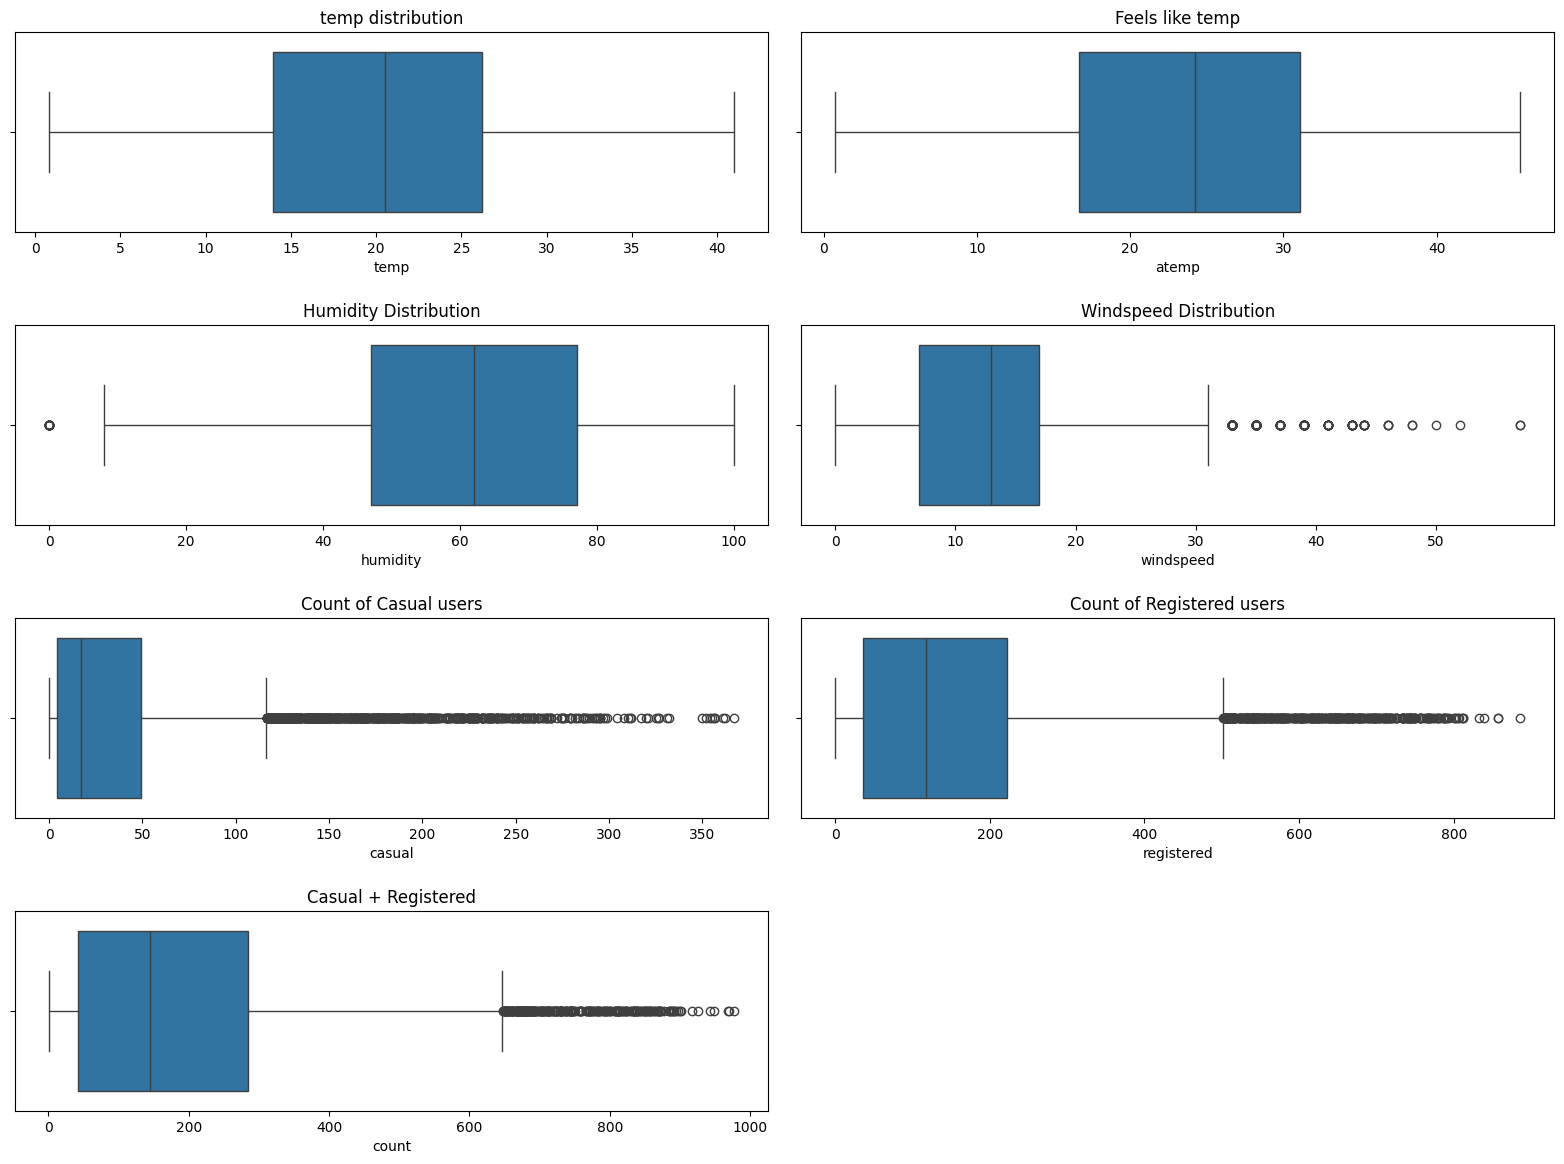

In [15]:
plt.figure(figsize=[16,12])

plt.subplot(4,2,1)
sns.boxplot(data=df,x=df['temp'])
plt.title("temp distribution")
plt.tight_layout(pad=2.0)


plt.subplot(4,2,2)
sns.boxplot(data=df,x=df['atemp'])
plt.title("Feels like temp")
plt.tight_layout(pad=2.0)


plt.subplot(4,2,3)
sns.boxplot(data=df,x=df['humidity'])
plt.title("Humidity Distribution")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,4)
sns.boxplot(data=df,x=df['windspeed'])
plt.title("Windspeed Distribution")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,5)
sns.boxplot(data=df,x=df['casual'])
plt.title("Count of Casual users")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,6)
sns.boxplot(data=df,x=df['registered'])
plt.title("Count of Registered users")
plt.tight_layout(pad=2.0)

plt.subplot(4,2,7)
sns.boxplot(data=df,x=df['count'])
plt.title("Casual + Registered")
plt.tight_layout(pad=2.0)
plt.show()

Humidity, Windspeed, Casual users, Registered users and Total Count users have outliers

Removing outliers using IQR method

In [16]:
for outlier in ['humidity','windspeed','casual','registered','count']:

  Q1 = np.percentile(df[outlier],25)
  Q3 = np.percentile(df[outlier],75)
  IQR = Q3-Q1

  lower_limit = Q1 - 1.5*IQR
  upper_limit = Q3 + 1.5*IQR

  df[outlier] = np.clip(df[outlier],lower_limit,upper_limit)

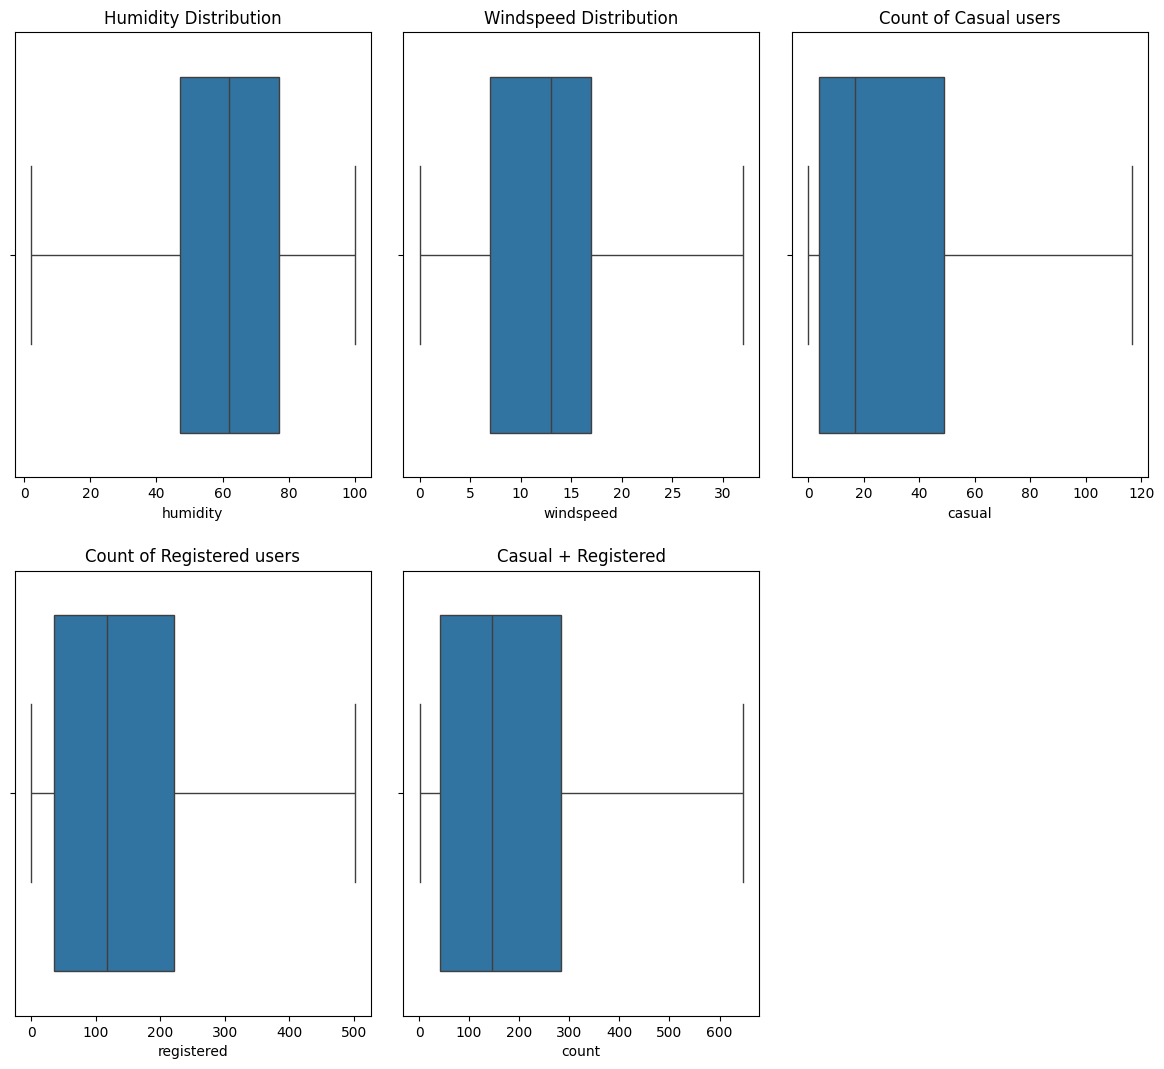

In [17]:
#Checking whether outliers have been removed from the dataset
plt.figure(figsize=[12,16])

plt.subplot(3,3,1)
sns.boxplot(data=df,x=df['humidity'])
plt.title("Humidity Distribution")
plt.tight_layout(pad=2.0)

plt.subplot(3,3,2)
sns.boxplot(data=df,x=df['windspeed'])
plt.title("Windspeed Distribution")
plt.tight_layout(pad=2.0)

plt.subplot(3,3,3)
sns.boxplot(data=df,x=df['casual'])
plt.title("Count of Casual users")
plt.tight_layout(pad=2.0)

plt.subplot(3,3,4)
sns.boxplot(data=df,x=df['registered'])
plt.title("Count of Registered users")
plt.tight_layout(pad=2.0)

plt.subplot(3,3,5)
sns.boxplot(data=df,x=df['count'])
plt.title("Casual + Registered")
plt.tight_layout(pad=2.0)
plt.show()

Outliers have successfully removed

###Correlation between variables

In [18]:
df_numerical = df.drop(columns=['datetime'])
df_numerical.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1,0,0,1,9.84,14.395,81,0.0,3.0,13,16
1,1,0,0,1,9.02,13.635,80,0.0,8.0,32,40
2,1,0,0,1,9.02,13.635,80,0.0,5.0,27,32
3,1,0,0,1,9.84,14.395,75,0.0,3.0,10,13
4,1,0,0,1,9.84,14.395,75,0.0,0.0,1,1


<Axes: >

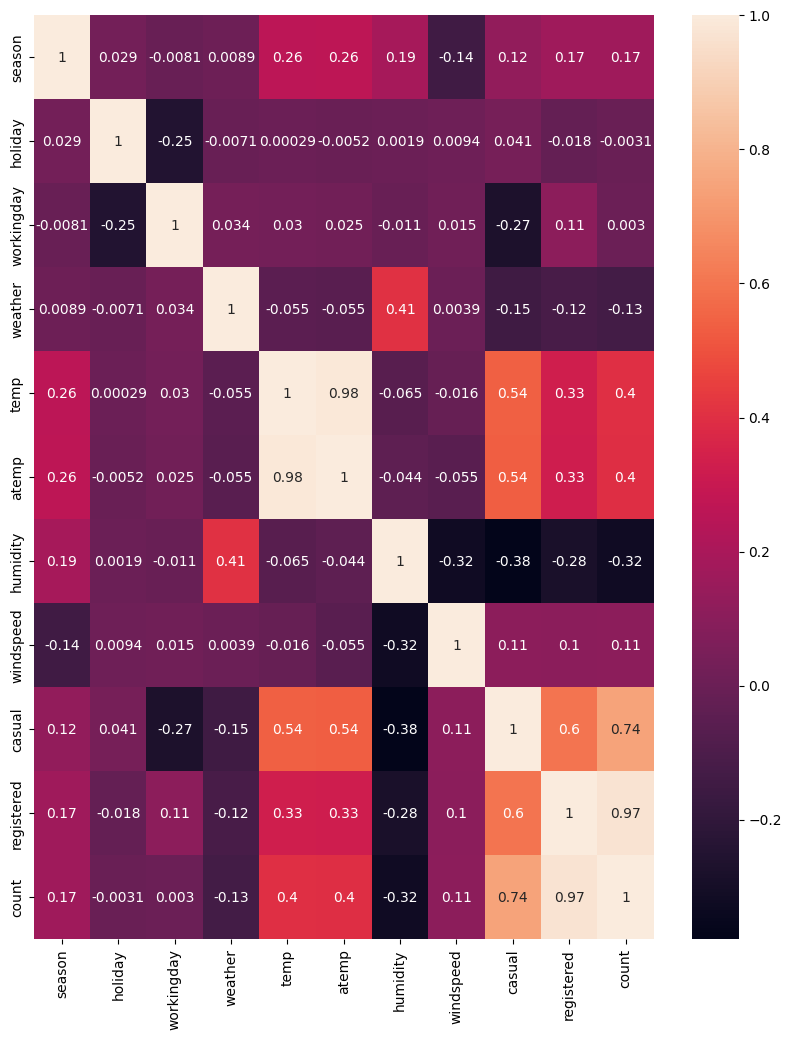

In [19]:
plt.figure(figsize=[10,12])
sns.heatmap(df_numerical.corr(),annot=True)

There is a good correlation between temp/atemp and count,
humidity and weather are also correlated

Highly correlated columns:
-casual vs count & registered
- registered vs count
- temp vs atemp


We can drop one of these columns.

##Hypothesis testing-1
H0 - No significant difference between bike rides on weekdays and weekends

H1 - There is a significant difference

Test - 2-sample independednt t-test

alpha = 0.05

In [20]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3.0,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8.0,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5.0,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3.0,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0.0,1,1


In [22]:
df_weekend = df[df['workingday']==0]['count']
df_weekday = df[df['workingday']==1]['count']

alpha = 0.05
tstat, pval = ttest_ind(df_weekend,df_weekday)
print(tstat, pval)

if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

-0.3163260408231243 0.7517611135576576
Fail to reject Null Hypothesis, There is no significant difference


Therefore we cannot confidently say that there is a significant difference in demand of bikes between weekday and weekend

##Hypothesis testing-2
H0: There is no significant difference on the demand of bicycles for different weather conditions

H1: There is a significant difference on the demand of bicycles for different weather conditions

-One-Way ANOVA test preferred due to multiple categories

Checking the assumptions of ANOVA
1. Normality (QQ Plot)

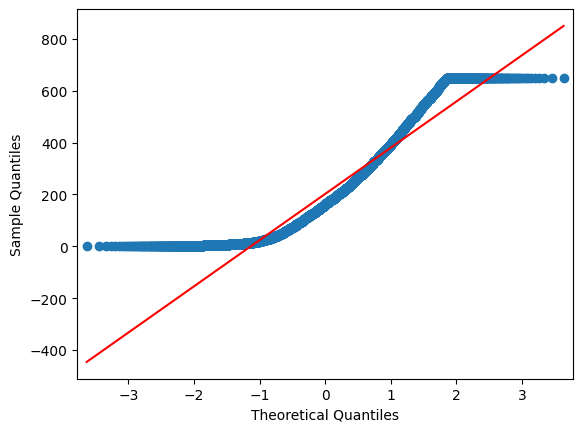

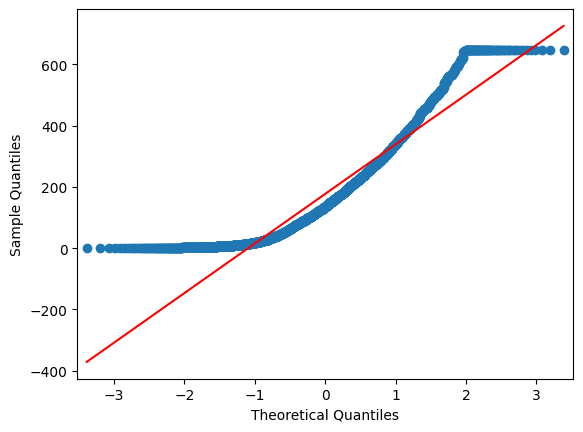

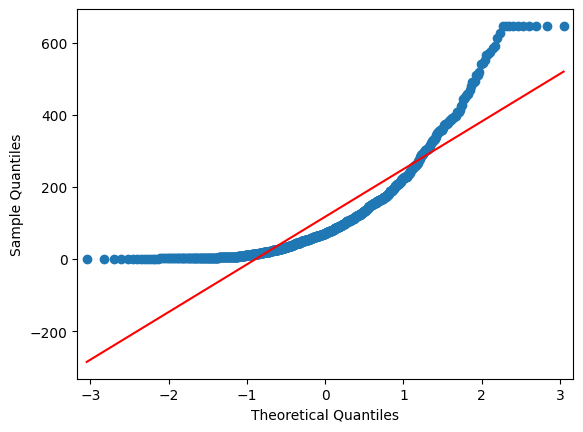

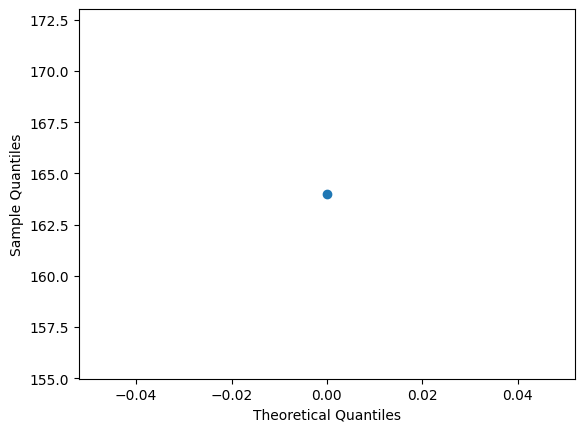

In [23]:
from statsmodels.graphics.gofplots import qqplot

df1 = df[df['weather']==1]['count']
df2 = df[df['weather']==2]['count']
df3 = df[df['weather']==3]['count']
df4 = df[df['weather']==4]['count']

qqplot(df1,line='s')
qqplot(df2,line='s')
qqplot(df3,line='s')
qqplot(df4,line='s')
plt.show()

Using QQ plot we can confirm that data is not normalized.

There is only 1 data point for weather 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog


2. Equality of Variance

H0: Variances are equal

H1: Variances are not equal

In [24]:
from scipy.stats import levene
levene_stat,pval = levene(df1,df2,df3,df4)

print(levene_stat,pval)

if pval < alpha:
  print("Reject Null Hypothesis, Variance are not equal")
else:
  print("Fail to reject Null Hypothesis, Variance is equal")

59.78620431801216 2.499984328437755e-38
Reject Null Hypothesis, Variance are not equal


Therefore the data does not have similar variance. However we will go ahead with further analysis.

One Way ANOVA test

H0: There is no significant difference on the demand of bicycles for different weather conditions

H1: There is a significant difference on the demand of bicycles for different weather conditions

In [25]:
from scipy.stats import f_oneway

fstat,pval = f_oneway(df1,df2,df3,df4)

if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Thus the weather condition does have a significant different on demand of bicycles.

We will conduct multiple independent t-test to check which weather condition most favours demand.

In [26]:
#df1 vs df2
tstat1,pval = ttest_ind(df1,df2,alternative='greater')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for weather 1: "Clear, Few clouds, partly cloudy" has HIGHER demand than 2: "Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist|



In [27]:
#df1 vs df3
tstat1,pval = ttest_ind(df1,df3,alternative='greater')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for weather 1: "Clear, Few clouds, partly cloudy" has HIGHER demand than 3: "Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds"



In [28]:
#df2 vs df3
tstat1,pval = ttest_ind(df2,df3,alternative='greater')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for weather 2: "Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist" has HIGHER demand than 3: "Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds"



We will not be comparing with weather 4 as it has only 1 data point.


There is a significant difference in demand based on weather.
Demand of cycles for weather followers the order

1 > 2 > 3 > 4

##Hypothesis Testing-3

H0: There is no significant difference in on the demand of bicycles for different seasons

H1: There is a significant difference in on the demand of bicycles for different seasons

-One-Way ANOVA test preferred due to multiple categories

Checking the assumptions of ANOVA
1. Normality (Shapiro Wilkins test)

H0: Data is gaussian

H1: Data is not gaussian

In [29]:
from scipy.stats import shapiro

dfs1 = df[df['season']==1]['count']
dfs2 = df[df['season']==2]['count']
dfs3 = df[df['season']==3]['count']
dfs4 = df[df['season']==4]['count']

j=1
for i in [dfs1,dfs2,dfs3,dfs4]:
  stat,pval = shapiro(i)
  if pval<alpha:
    print(f"For season{j} the data is not gaussian")
  else:
    print(f"For season{j} the data is gaussian")
  j+=1

For season1 the data is not gaussian
For season2 the data is not gaussian
For season3 the data is not gaussian
For season4 the data is not gaussian


It is observed that the distribution for each season does not follow a gaussian distribution. However we will continue with analysis

2. Equality Variance

H0: Variances are equal

H1: Variances are not equal

In [30]:
levene_stat,pval = levene(dfs1,dfs2,dfs3,dfs4)

print(levene_stat,pval)

if pval < alpha:
  print("Reject Null Hypothesis, Variance are not equal")
else:
  print("Fail to reject Null Hypothesis, Variance is equal")

199.5119672794296 5.7233179707619984e-126
Reject Null Hypothesis, Variance are not equal


Therefore the datasets do not have similar variances

One Way ANOVA test

H0: There is no significant difference in on the demand of bicycles for different seasons

H1: There is a significant difference in on the demand of bicycles for different seasons

In [31]:
fstat,pval = f_oneway(dfs1,dfs2,dfs3,dfs4)

if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Thus the season does have a significant different on demand of bicycles.

We will conduct multiple independent t-test to check which season most favours demand.

In [32]:
#dfs1 vs dfs2
tstat1,pval = ttest_ind(dfs1,dfs2,alternative='less')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for season 2: Summer is GREATER than in 1: Spring


In [33]:
#dfs1 vs dfs3
tstat1,pval = ttest_ind(dfs1,dfs3,alternative='less')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for season 3: Fall is GREATER than in 1: Spring

In [34]:
#dfs1 vs dfs4
tstat1,pval = ttest_ind(dfs1,dfs4,alternative='less')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for season 4: Winter is GREATER than in 1: Spring


In [35]:
#dfs2 vs dfs3
tstat1,pval = ttest_ind(dfs3,dfs2,alternative='greater')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles for season 3: Fall is significantly GREATER than in 2: Summer


In [36]:
#dfs2 vs dfs4
tstat1,pval = ttest_ind(dfs2,dfs4,alternative='greater')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles in season 2:Summer is significantly GREATER than in 4: Winter


In [37]:
#dfs3 vs dfs4
tstat1,pval = ttest_ind(dfs3,dfs4,alternative='greater')
if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Demand of cycles in season 3:Fall is significantly GREATER than in 4: Winter


Therefore there is a significant difference in demand based on seasons

Order of cycle demand with respect to seasons

Fall > Summer > Spring > Winter

##Hypothesis Testing-4

H0: There is no significant difference between weather conditions and seasons

H1: There is significant difference between weather conditions and seasons

We will use Chi-square test for independence


In [38]:
#Create contingency table
weather = df['weather']
season = df['season']

pd.crosstab(weather,season)

season,1,2,3,4
weather,,,,
1,1759,1801,1930,1702
2,715,708,604,807
3,211,224,199,225
4,1,0,0,0


In [40]:
from scipy.stats import chi2_contingency

observed = [[1759,1801,1930,1702],[715,708,604,807],[211,224,199,225],[1,0,0,0]]

test_stat,pval,dof,expected_values = chi2_contingency(observed)

if pval < alpha:
  print("Reject Null Hypothesis, There is a significant difference")
else:
  print("Fail to reject Null Hypothesis, There is no significant difference")

Reject Null Hypothesis, There is a significant difference


Weather conditions are significantly different during different seasons.

This means that weather conditions are not dependent on seasons.

#Recommendation based on analysis

1. There is consistent demand of Yulu cycles across weekdays and weekends. That means people use it for "commuting to work" and "leisure". General promotions should be focused on rather than weekday or weekend focused promotions. Yulu can ensure same availability of cycles on weekdays and weekends.

2. There is a significant difference on demand of cycles based on weather. Where demand is highest for when weather is sunny or cloudy as it is more preferred to commute in these weathers. There is lower demand for cycles when there is lgiht rain or severe weather. Yulu must ensure high availability of cycles during the sunny and cloudy weather to get maximum revenue. During the rainy or severe weather Yulu should ensure the safety of the person by purchasing anti-slip tires. Due to lower demand Yulu can focus on maintenance of their cycles. They can also target special promotions during periods of severe weather.

3. The cycle rental demand varies significantly with the seasons. In the order Fall>Summer>Spring>Winter. Due to high demand in the Fall and Summer season, Yulu must ensure availability of cycles during this period. Yulu can focus their promotions on the Fall time to bring new customers. They can introduce discounts during the winter to encourage usage.

4. As there weather conditions are significantly different during different seasons, Yulu can tailor their strategy for each type of weather and season. Based on the weather and demand Yulu can alter their pricing to match the demand.